# Conda Environment: dendropy

---

# Library Imports

In [1]:
# For data management and visualisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# For running R through Python
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# R libraries needed
importr('ape')
importr('geiger')
importr('qpcR');

---

# Make Output Directories

In [2]:
!mkdir -p ../Datasets/Trait_evolution/All_models
!mkdir -p ../Figures/Trait_evolution

---

# Fitting Models of Trait Evolution

In [25]:
# Find best fitting model using Geiger::fitContinuous
models = ['white','kappa','delta','BM','EB','lambda','rate_trend']
traits = ['Optimum','Bn','lowT_fitness','highT_fitness','TwoWeeks_fitness','OneWeek_fitness','TwoDays_fitness']

ro.r(f'''
# Read in tree
tree = read.tree('../Datasets/Tree/Ultrametric_tree.nwk')

# Get tree tip labels
tips = tree$tip.label
write.csv(tips,'../Datasets/Tree/tips.csv')

# Read in trait values
trait = read.csv('../Datasets/ASV_trait_data.csv',sep=',')

# Get indices of ASVs of interest
index_vector <- match(tips, trait$ASV)

# Select and reorder
trait = trait[index_vector,]
''')

for trait in traits:
    ro.r("model_data = c()")
    ro.r("model_names= c()")
    for model in models:
        # Run all models and store AICc values
        ro.r(f'''
        set.seed(11)
        
        # Create reordered trait vector
        trait_values = as.vector(trait${trait})
        #write.csv(trait, 'trait_data/leaves_optima.csv')
        names(trait_values) = tips
        
        model = fitContinuous(phy= tree, dat= trait_values, model= '{model}',control = list(method = c("subplex","L-BFGS-B"),
            niter = 100, FAIL = 1e+200, hessian = FALSE))

        # Append model name and AICc to list
        model_names = c(model_names, '{model}')
        model_data = c(model_data, model$opt$aicc)
        ''')

    # Find best fitting model
    ro.r(f'''
    set.seed(11)
    # Calculate Akaike weights of the different models
    akaike_weights = akaike.weights(model_data)
    df = data.frame(model_names, akaike_weights$weights)
    
    # Get name and Akaike weight of best performing model
    best_model = df[which.max(df$akaike_weights.weights),]$model_names
    best_aw = df[which.max(df$akaike_weights.weights),]$akaike_weights.weights
    
    # (re)fit best performing model
    model = fitContinuous(phy= tree, dat= trait_values, model= best_model, control = list(method = c("subplex","L-BFGS-B"),
            niter = 1000, FAIL = 1e+200, hessian = TRUE, CI = 0.95))

    parameter_value = get('model')$opt[[best_model]]

    # Print result
    report = paste0('The best performing model for {trait} is ',best_model,' = ',round(parameter_value,2),'; Akaike weight = ',round(best_aw,2),'.')
    print(report)

    # Output model to file
    sink('../Datasets/Trait_evolution/{trait}_model.txt')
    print(model)
    sink()
    ''')

[1] "The best performing model for Optimum is lambda = 0.37; Akaike weight = 1."
[1] "The best performing model for Bn is lambda = 0.51; Akaike weight = 1."
[1] "The best performing model for lowT_fitness is lambda = 0.35; Akaike weight = 1."
[1] "The best performing model for highT_fitness is lambda = 0.11; Akaike weight = 0.92."
[1] "The best performing model for TwoWeeks_fitness is lambda = 0.57; Akaike weight = 1."
[1] "The best performing model for OneWeek_fitness is lambda = 0.16; Akaike weight = 0.98."
[1] "The best performing model for TwoDays_fitness is lambda = 0.09; Akaike weight = 0.74."


# Likelihood Ratio Testing for Different Values of Lambda for Niche breadth and Optimum Temperature

In [3]:
# Likelihood ratio test

trait1= 'Bn'
trait2 = 'Optimum'
model = 'lambda'

ro.r(f'''
set.seed(11)
# Read in tree
tree = read.tree('../Datasets/Tree/Ultrametric_tree.nwk')

# Get tree tip labels
tips = tree$tip.label
write.csv(tips,'../Datasets/Tree/tips.csv')

# Read in trait values
trait = read.csv('../Datasets/ASV_trait_data.csv',sep=',')

# Get indices of ASVs of interest
index_vector <- match(tips, trait$ASV)

# Select and reorder
trait = trait[index_vector,]

# Create reordered trait vector
{trait1}_values = as.vector(trait${trait1})
{trait2}_values = as.vector(trait${trait2})
names({trait1}_values) = tips
names({trait2}_values) = tips

# Run fitContinuous for niche breadth (Bn)
{trait1}_fit = fitContinuous(phy= tree, dat= {trait1}_values, model= '{model}',control = list(method = c("subplex","L-BFGS-B"),
    niter = 1000, FAIL = 1e+200, hessian = TRUE, CI = 0.95))

# Run fitContinuous with unconstrained lambda for optimum temperature
unconstrained = fitContinuous(phy= tree, dat= {trait2}_values, model= '{model}',control = list(method = c("subplex","L-BFGS-B"),
    niter = 1000, FAIL = 1e+200, hessian = TRUE, CI = 0.95))

# Run fitContinuous with constrained lambda by rescaling tree and fitting BM model
rescaled_phy <- rescale(x= tree, model = "lambda", lambda = {trait1}_fit$opt$lambda)
constrained <- fitContinuous(phy= rescaled_phy, dat= {trait2}_values, model = "BM", control = list(method = c("subplex","L-BFGS-B"),
    niter = 1000, FAIL = 1e+200, hessian = TRUE, CI = 0.95))

# Extract log likelihood values
unconstrained_lnL = unconstrained$opt$lnL
constrained_lnL = constrained$opt$lnL

# Likelihood ratio test
LR = -2 * (constrained_lnL - unconstrained_lnL)
p_value = pchisq(LR, df = 1, lower.tail = FALSE)
''')


0.094014


In [4]:
Optimum_CI = list(ro.r('unconstrained$opt$CI'))[:2]
Optimum_CI.insert(0, ro.r('unconstrained$opt$lambda')[0])

Bn_CI = list(ro.r('Bn_fit$opt$CI'))[:2]
Bn_CI.insert(0, ro.r('Bn_fit$opt$lambda')[0])

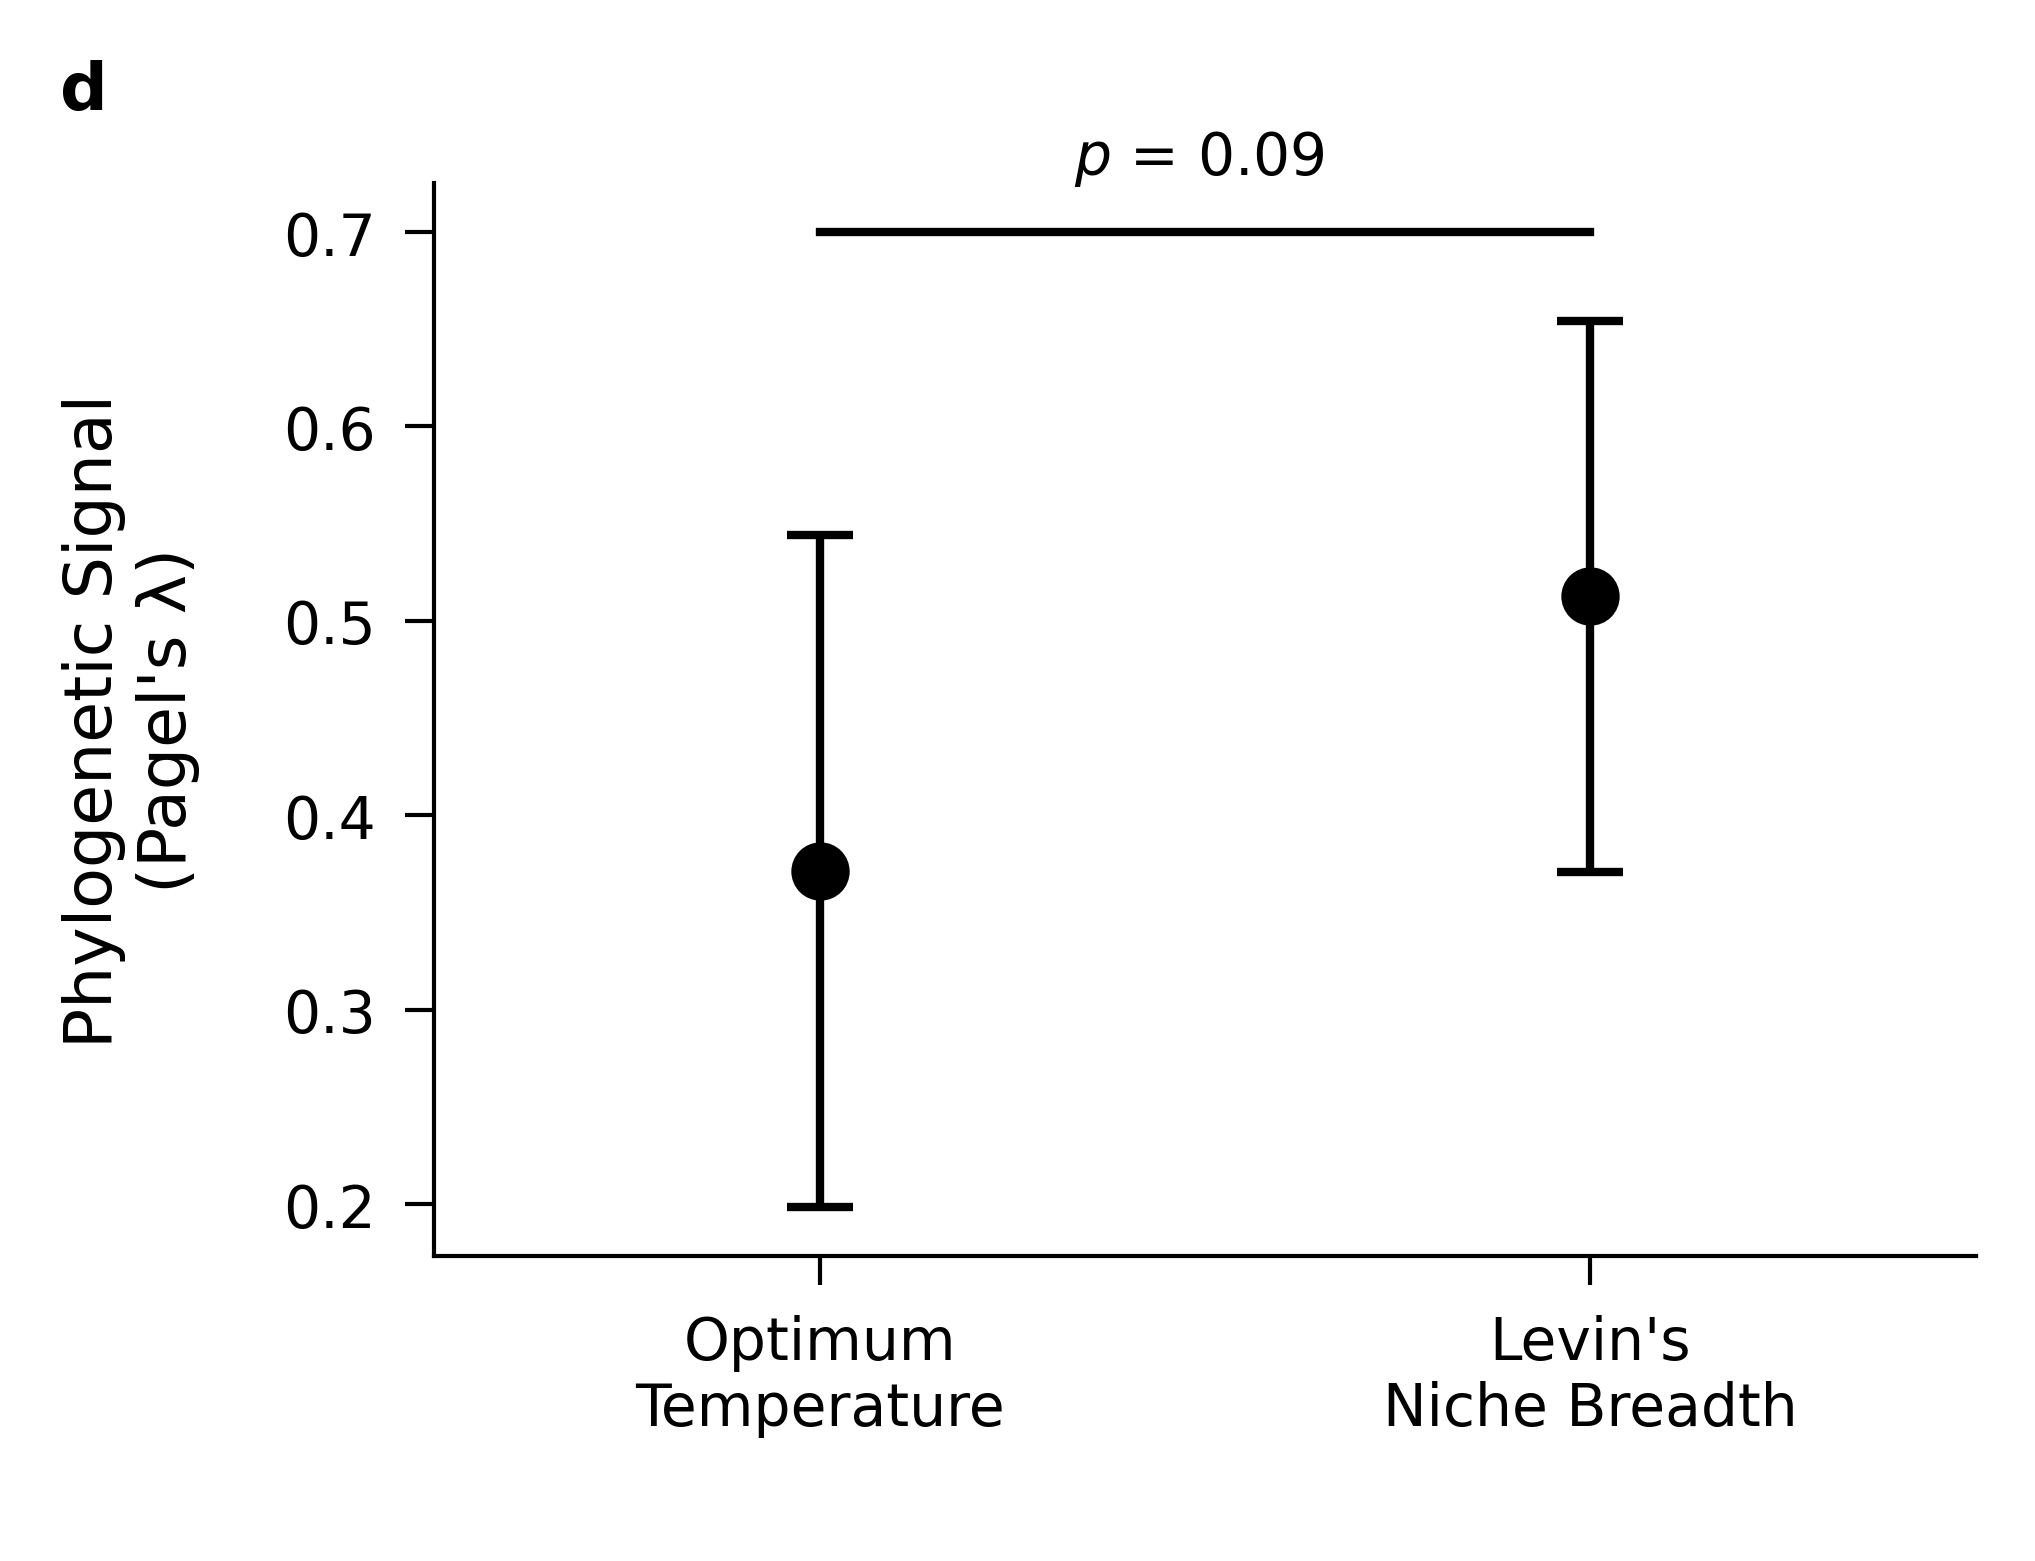

In [16]:
plt.style.use("../nature.mplstyle")

# Create axes to plot on
fig, ax = plt.subplots(figsize= (3.4,2.5), dpi= 600)

# Add mean and error bars for Optimum
ax.scatter(x= 'Optimum', y= Optimum_CI[0], color= 'black')
ax.errorbar(x= 'Optimum', y= Optimum_CI[0], yerr= (Optimum_CI[2] - Optimum_CI[1])/2, color= 'black', capsize= 4)

# Add mean and error bars for Niche breadth
ax.scatter(x= 'Niche Breadth', y= Bn_CI[0], color= 'black')
ax.errorbar(x= 'Niche Breadth', y= Bn_CI[0], yerr= (Bn_CI[2] - Bn_CI[1])/2, color= 'black', capsize= 4)

# Add p value from likelihood ratio test
p_value = np.round(ro.r("p_value")[0],2)
plt.text(x= 0.33, y= 0.73, s= f"$p$ = {p_value}")
plt.axhline(y= 0.7, xmin= 0.25, xmax= 0.75, color= 'black')

# Tidy up
ax.spines[['top','right']].set_visible(False)
plt.ylabel("Phylogenetic Signal\n(Pagel's λ)", labelpad= 10)
plt.xticks(ticks= ax.get_xticks(), labels= ["Optimum\nTemperature", "Levin's\nNiche Breadth"])
#ax.tick_params(axis='x', which='major', pad=10)
ax.set_xlabel(' ', labelpad= 0)
ax.margins(x= 0.5)
plt.tight_layout()

# Add panel letter
fig.text(x= 0.03, y= 0.97, s= 'd', weight= 'bold', fontsize= 8)

# Save to file
plt.savefig("../Figures/Trait_evolution/Phylogenetic_signal_Optimum_Bn.svg");

---
# Relationship of Optimum Temperature and Niche Breadth Values

## Spearman Correlation

In [19]:
from scipy.stats import spearmanr

# Import optimum temperature and niche breadth data
optima = pd.read_csv("../Datasets/Optimum_temperature/Optima.csv")
niche_breadth = pd.read_csv("../Datasets/Niche_breadth/StageOneActive_NicheBreadth.csv", index_col= 0).reset_index(names= 'ASV_ID')

# Subset niche breadth to only those taxa above the limit of quantitation
niche_breadth = niche_breadth.query("`Below.LOQ` == 'N'")
assert len(niche_breadth) == len(optima)

# Take only columns of interest
niche_breadth = niche_breadth[['ASV_ID','Bn']]

# Merge datasets
data = pd.merge(left= niche_breadth, right= optima, how= 'left', on= 'ASV_ID')


# Spearman correlation of niche breadth and optimum temperature
x = data['Optimum']
y = data['Bn']

spearman = spearmanr(x,y, alternative= 'two-sided')
print(f"Spearman correlation coefficient: {spearman.statistic:.2f}\np value: {spearman.pvalue}")

Spearman correlation coefficient: -0.27
p value: 4.308148742461816e-47
